In [ ]:
# SVM


"""
Business Context
Pharmaceutical companies invest millions of dollars in clinical trials to test drug efficacy. However, some drugs do not work for all patients due to individual differences in biology, metabolism, and pre-existing conditions.
Traditional clinical trials take years to conclude, with high costs and risks.
Machine learning models can help predict drug response early, saving time and resources.
Personalized medicine ensures that patients receive the right drug at the right dose.
-------------------------------------------------------------------------------------------------------------------------------
Drug Response Classification (0 = No response, 1 = Positive response)
Drug response classification refers to how a patient’s body reacts to a particular drug. This is a key concept in pharmaceutical research and clinical trials, where researchers analyze whether a drug is effective or not based on biological responses.
Interpretation of Classification Labels:
1.	0 = No Response
o	The drug did not have a significant effect on the patient.
o	The patient’s condition remained unchanged after taking the drug.
o	The biomarkers (e.g., blood pressure, glucose level, heart rate) did not improve.
o	Possible reasons:
	The drug is not suitable for the patient.
	The dosage is ineffective.
	The patient's metabolism is resistant to the drug.
2.	1 = Positive Response
o	The drug had a beneficial effect on the patient.
o	The patient’s condition improved after taking the drug.
o	Biomarkers such as blood pressure, glucose levels, and enzyme activity show significant improvement.
o	Possible reasons:
	The drug is effective for this patient.
	The dosage is appropriate.
	The patient’s metabolism responds well to the drug.
"""

"""

Dataset Selection:
Data set Description described in another document “Drug Response Classification”
Task 1: Exploratory Data Analysis (EDA)
1.	Load the dataset and perform fundamental data exploration.
2.	Utilize histograms, box plots, or density plots to understand feature distributions.
3.	Investigate feature correlations to discern relationships within the data.
Task 2: Data Preprocessing
1.	Encode categorical variables if necessary.
2.	Split the dataset into training and testing sets.
Task 3: Data Visualization
1.	Employ scatter plots, pair plots, or relevant visualizations to comprehend feature distributions and relationships.
2.	Visualize class distributions to gauge dataset balance or imbalance.
Task 4: SVM Implementation
1.	Implement a basic SVM classifier using Python libraries like scikit-learn.
2.	Train the SVM model on the training data.
3.	Evaluate model performance on the testing data using appropriate metrics (e.g., accuracy, precision, recall, F1-score).
Task 5: Visualization of SVM Results
1.	Visualize classification results on the testing data.
Task 6: Parameter Tuning and Optimization
1.	Experiment with different SVM hyperparameters (e.g., kernel type, regularization parameter) to optimize performance.
Task 7: Comparison and Analysis
1.	Compare SVM performance with various kernels (e.g., linear, polynomial, radial basis function).
2.	Analyze SVM strengths and weaknesses for the dataset based on EDA and visualization results.
3.	Discuss practical implications of SVM in real-world classification tasks.

"""


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

In [3]:
# Load data
df = pd.read_csv('Assi_10_Pharma_Industry.csv')

In [4]:
# TASK 1: EXPLORATORY DATA ANALYSIS



In [5]:
print("\nDataset Shape:", df.shape)


Dataset Shape: (500, 6)


In [6]:
print("\nColumn Names:", list(df.columns))


Column Names: ['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)', 'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)', 'Blood Glucose Level (mg/dL)', 'Drug Response']


In [7]:
print("\nFirst 5 rows:")
print(df.head())


First 5 rows:
   Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
0         -0.128538                        0.303280         -1.881849   
1         -1.846188                        2.865142         -0.929511   
2         -1.252393                       -1.541613          0.363632   
3          1.992515                       -1.142779         -0.766657   
4          0.377100                        0.538410         -0.029263   

   Liver Toxicity Index (U/L)  Blood Glucose Level (mg/dL)  Drug Response  
0                    0.258286                    -0.792011              1  
1                    2.866786                    -0.719447              1  
2                   -0.325370                     0.191314              0  
3                    0.975286                    -0.823355              1  
4                    1.896015                    -0.960130              1  


In [8]:
print("\nData Types:")
print(df.dtypes)


Data Types:
Drug Dosage (mg)                  float64
Systolic Blood Pressure (mmHg)    float64
Heart Rate (BPM)                  float64
Liver Toxicity Index (U/L)        float64
Blood Glucose Level (mg/dL)       float64
Drug Response                       int64
dtype: object


In [9]:
print("\nMissing Values:", df.isnull().sum().sum())


Missing Values: 0


In [10]:
print("\nStatistical Summary:")
print(df.describe())


Statistical Summary:
       Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
count        500.000000                      500.000000        500.000000   
mean          -0.037761                        0.214957          0.062871   
std            0.979891                        1.247567          0.971978   
min           -3.019512                       -3.773897         -2.940389   
25%           -0.642003                       -0.565168         -0.648157   
50%           -0.019340                        0.201532          0.027732   
75%            0.641151                        0.951375          0.710774   
max            2.949094                        4.111751          3.193108   

       Liver Toxicity Index (U/L)  Blood Glucose Level (mg/dL)  Drug Response  
count                  500.000000                   500.000000       500.0000  
mean                     0.054398                    -0.171863         0.5200  
std                      0.986001           

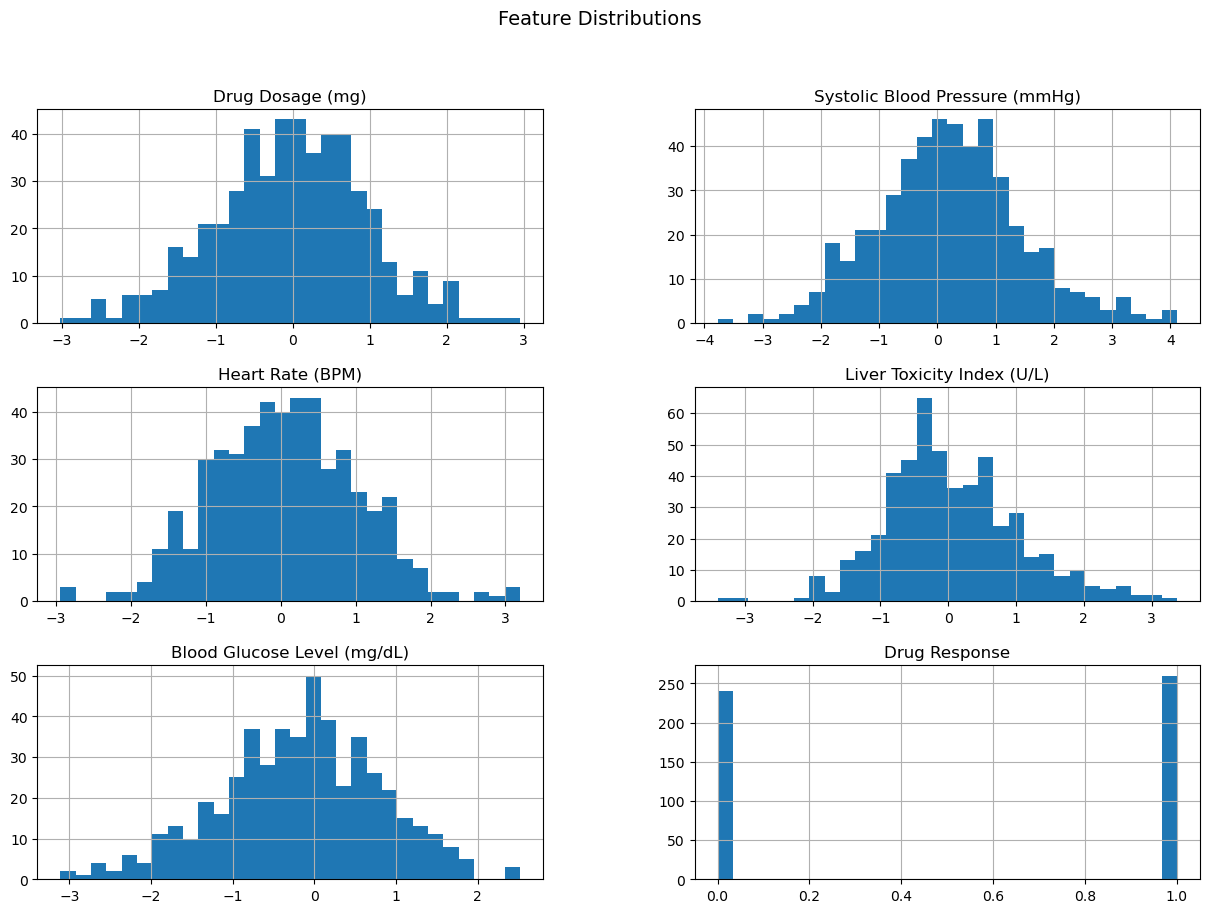

In [11]:
# Histograms
df.hist(figsize=(15, 10), bins=30)
plt.suptitle("Feature Distributions", fontsize=14)
plt.savefig('histograms.png')
plt.show()

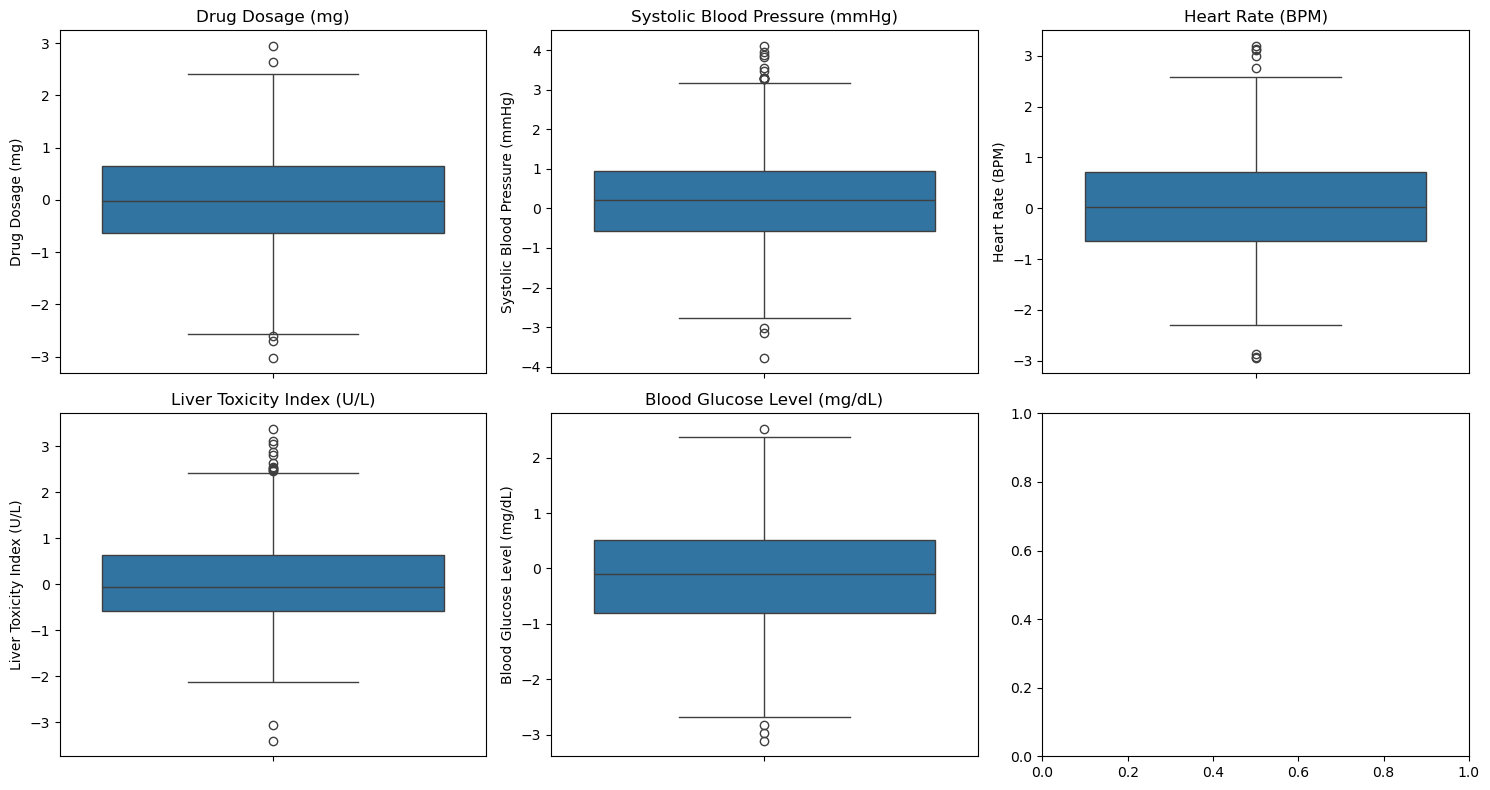

In [12]:
# Box plots
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for i, col in enumerate(df.columns[:-1]):
    sns.boxplot(y=df[col], ax=axes[i//3, i%3])
    axes[i//3, i%3].set_title(col)
plt.tight_layout()
plt.savefig('boxplots.png')
plt.show()


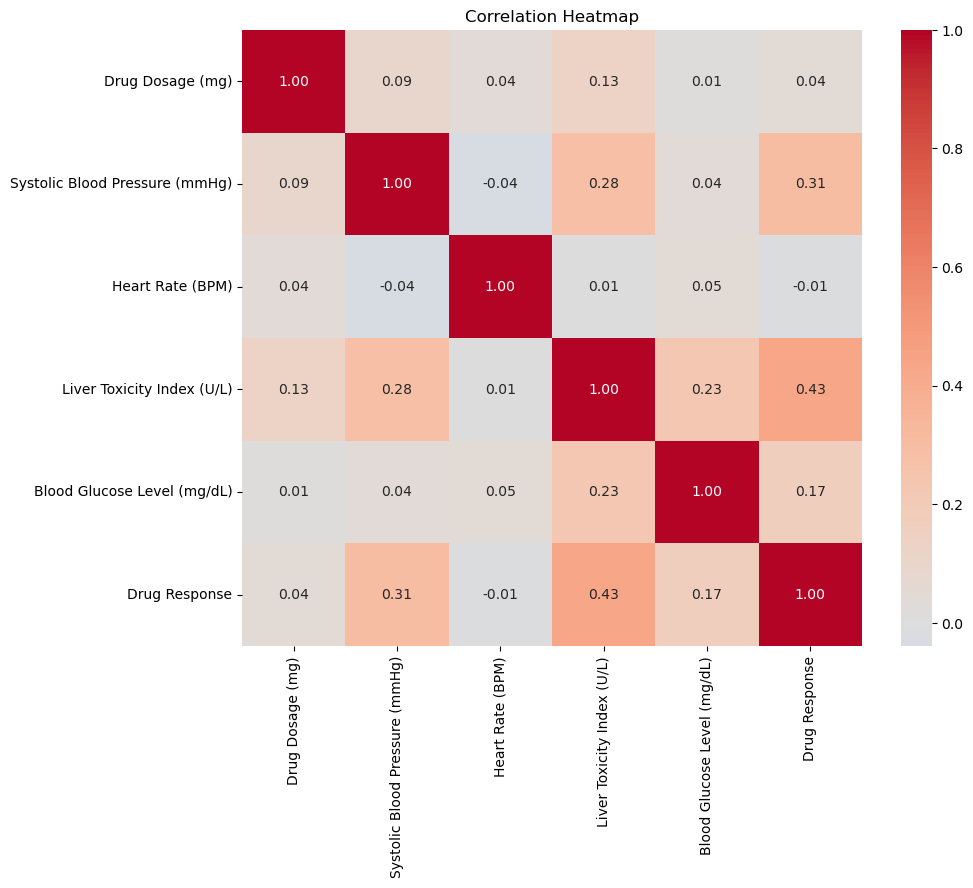

In [13]:
# Correlation
plt.figure(figsize=(10, 8))
corr = df.corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title("Correlation Heatmap")
plt.savefig('correlation.png')
plt.show()

In [14]:
# TASK 2: DATA PREPROCESSING




In [15]:
print("All features are numerical. No encoding required.")


All features are numerical. No encoding required.


In [16]:
# Split data
X = df.drop('Drug Response', axis=1)
y = df['Drug Response']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTraining set size: {X_train.shape}")
print(f"Test set size: {X_test.shape}")
print(f"Class distribution in training: 0={(y_train==0).sum()}, 1={(y_train==1).sum()}")
print(f"Class distribution in test: 0={(y_test==0).sum()}, 1={(y_test==1).sum()}")



Training set size: (400, 5)
Test set size: (100, 5)
Class distribution in training: 0=192, 1=208
Class distribution in test: 0=48, 1=52


In [17]:
# Standardize features (important for SVM)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("\nFeatures standardized (mean=0, std=1)")



Features standardized (mean=0, std=1)


In [18]:
# TASK 3: DATA VISUALIZATION



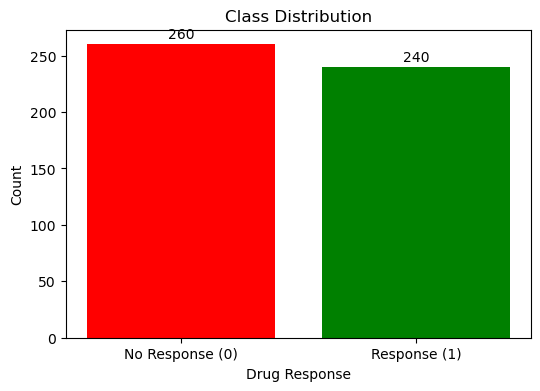


Class Distribution:
Class 0 (No Response): 240 samples (48.0%)
Class 1 (Response): 260 samples (52.0%)


In [19]:
# Class distribution
plt.figure(figsize=(6, 4))
counts = df['Drug Response'].value_counts()
plt.bar(['No Response (0)', 'Response (1)'], counts.values, color=['red', 'green'])
plt.xlabel('Drug Response')
plt.ylabel('Count')
plt.title('Class Distribution')
for i, v in enumerate(counts.values):
    plt.text(i, v+5, str(v), ha='center')
plt.savefig('class_distribution.png')
plt.show()

print(f"\nClass Distribution:")
print(f"Class 0 (No Response): {counts[0]} samples ({counts[0]/len(df)*100:.1f}%)")
print(f"Class 1 (Response): {counts[1]} samples ({counts[1]/len(df)*100:.1f}%)")

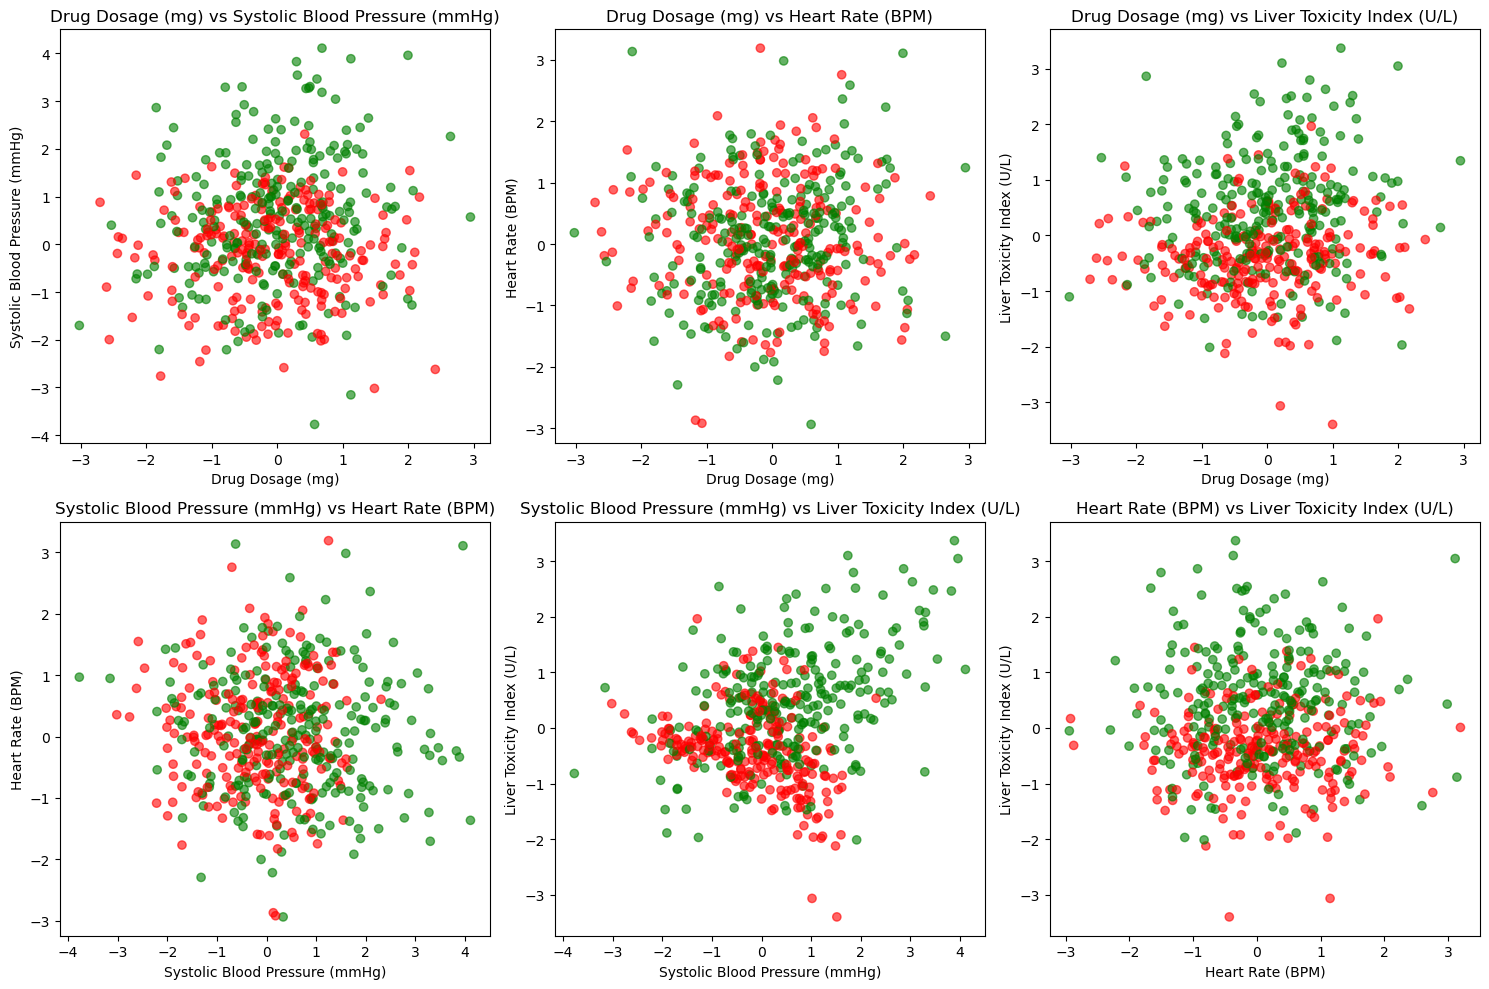

In [20]:
# Scatter plots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
colors = ['red' if x==0 else 'green' for x in df['Drug Response']]
scatter_pairs = [(0,1), (0,2), (0,3), (1,2), (1,3), (2,3)]
for idx, (i, j) in enumerate(scatter_pairs):
    ax = axes[idx//3, idx%3]
    ax.scatter(df.iloc[:, i], df.iloc[:, j], c=colors, alpha=0.6)
    ax.set_xlabel(df.columns[i])
    ax.set_ylabel(df.columns[j])
    ax.set_title(f'{df.columns[i]} vs {df.columns[j]}')
plt.tight_layout()
plt.savefig('scatter_plots.png')
plt.show()

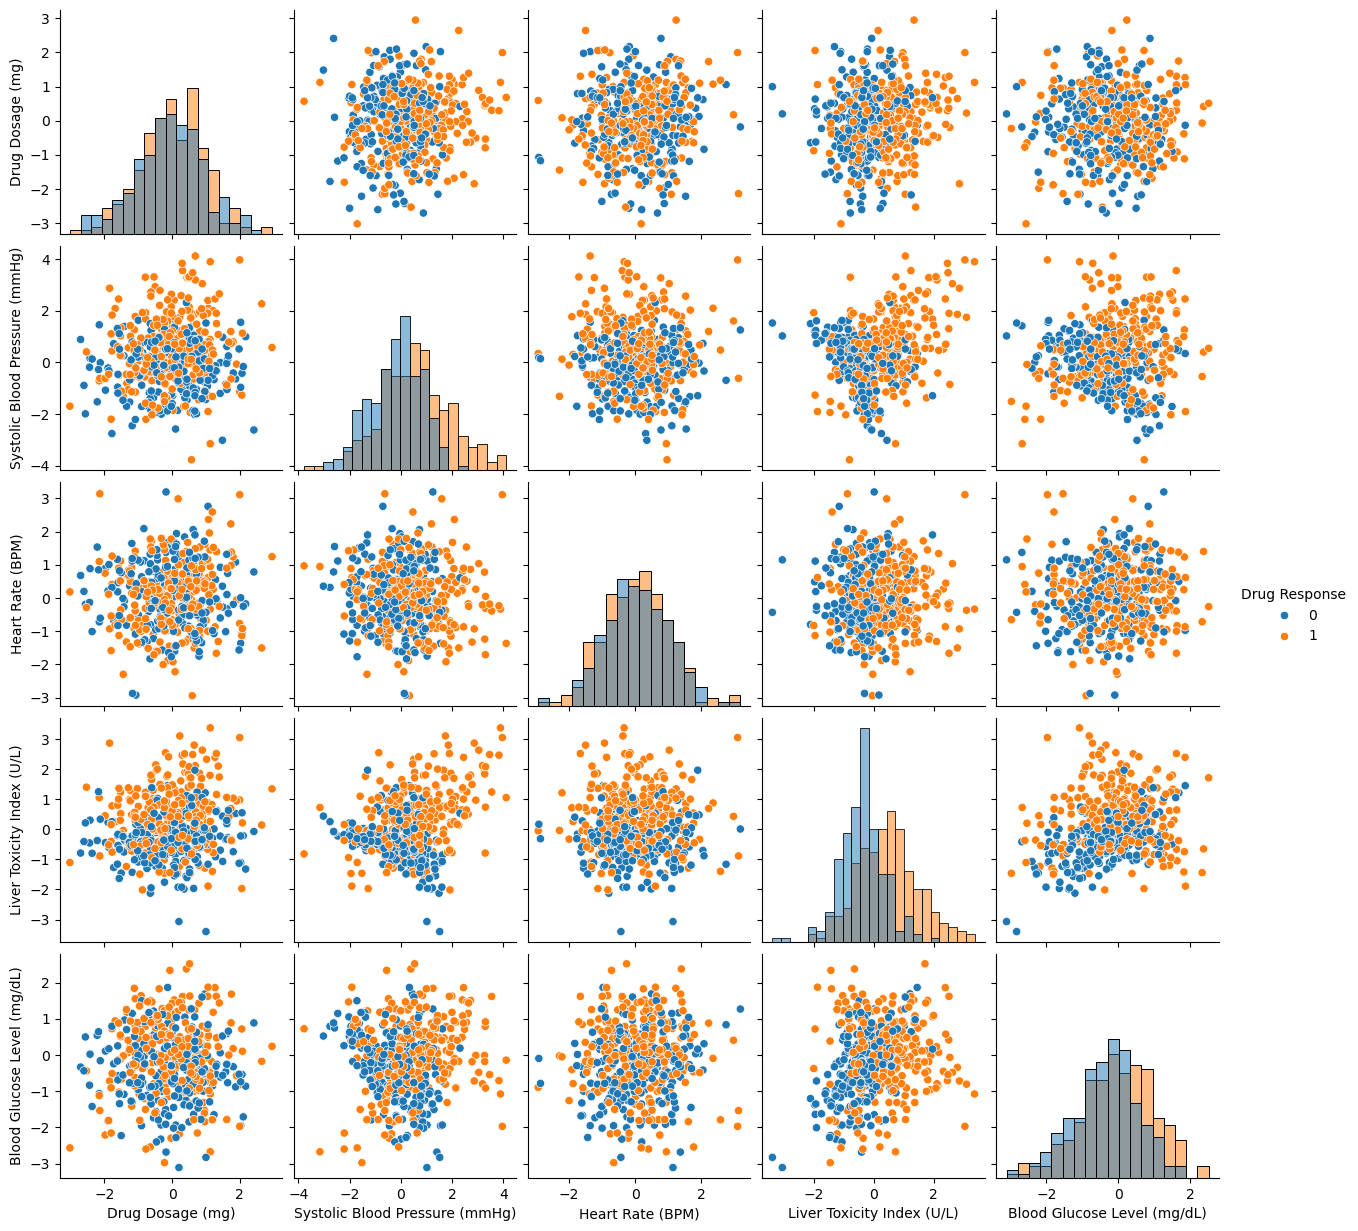

In [22]:
# Pair plot for selected features
sns.pairplot(df, hue='Drug Response', diag_kind='hist')
plt.savefig('pairplot.png')
plt.show()

In [23]:
# TASK 4: SVM IMPLEMENTATION




In [24]:
# Basic SVM with RBF kernel
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train_scaled, y_train)

y_pred = svm.predict(X_test_scaled)

print("\nBasic SVM (RBF kernel) Performance:")
print("-"*40)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")


print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score:  {f1_score(y_test, y_pred):.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Response', 'Response']))

cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print("               Predicted")
print("               No    Yes")
print(f"Actual No     {cm[0,0]:3d}   {cm[0,1]:3d}")
print(f"Actual Yes    {cm[1,0]:3d}   {cm[1,1]:3d}")


Basic SVM (RBF kernel) Performance:
----------------------------------------
Accuracy:  0.7700
Precision: 0.7544
Recall:    0.8269
F1-Score:  0.7890

Classification Report:
              precision    recall  f1-score   support

 No Response       0.79      0.71      0.75        48
    Response       0.75      0.83      0.79        52

    accuracy                           0.77       100
   macro avg       0.77      0.77      0.77       100
weighted avg       0.77      0.77      0.77       100


Confusion Matrix:
               Predicted
               No    Yes
Actual No      34    14
Actual Yes      9    43


In [25]:
# TASK 5: VISUALIZATION OF SVM RESULTS

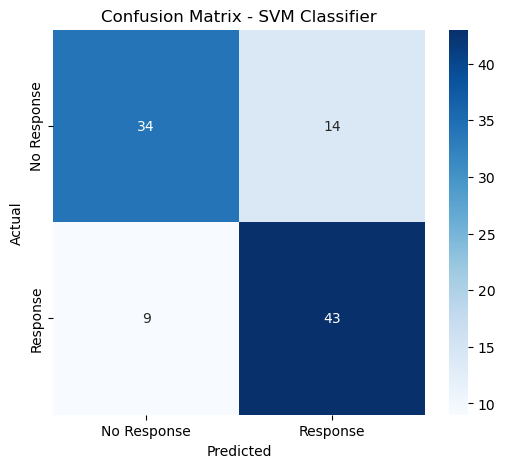

In [26]:
# Confusion Matrix Heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['No Response', 'Response'],
            yticklabels=['No Response', 'Response'])
plt.title('Confusion Matrix - SVM Classifier')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.savefig('confusion_matrix_svm.png')
plt.show()

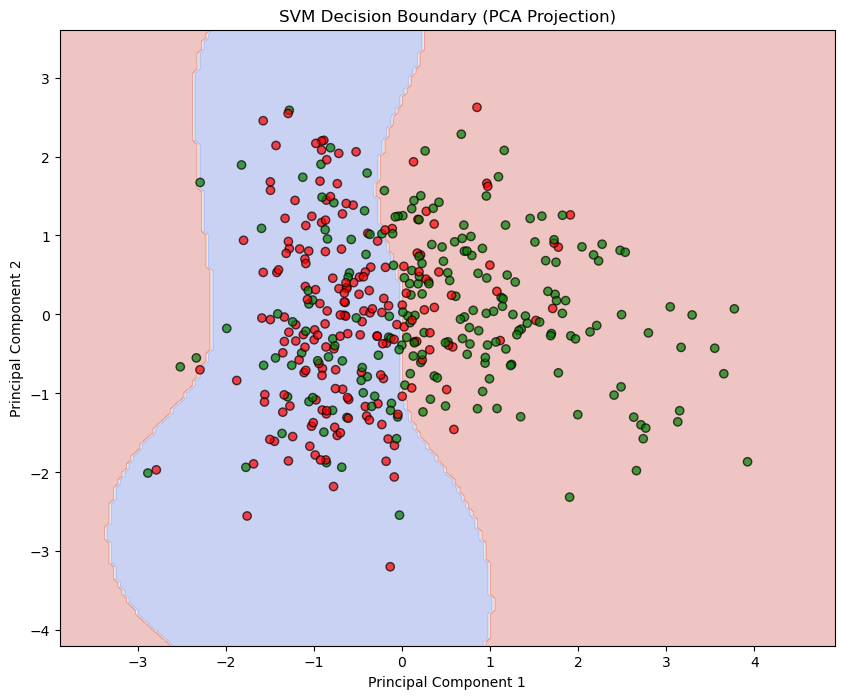

In [27]:

# Decision boundary using first two features (PCA for visualization)
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_train_scaled)
svm_pca = SVC(kernel='rbf')
svm_pca.fit(X_pca, y_train)

x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.05), np.arange(y_min, y_max, 0.05))
Z = svm_pca.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.figure(figsize=(10, 8))

plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
colors_pca = ['red' if x==0 else 'green' for x in y_train]
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=colors_pca, edgecolors='black', alpha=0.7)
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.title('SVM Decision Boundary (PCA Projection)')
plt.savefig('decision_boundary.png')
plt.show()

In [28]:
# TASK 6: PARAMETER TUNING AND OPTIMIZATION




In [29]:
# Experiment 1: Different Kernels
print("\n1. KERNEL COMPARISON (C=1, gamma='scale'):")
print("-"*50)
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
kernel_results = []
for kernel in kernels:
    svm_k = SVC(kernel=kernel, random_state=42)
    svm_k.fit(X_train_scaled, y_train)
    y_pred_k = svm_k.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred_k)
    kernel_results.append((kernel, acc))
    print(f"  {kernel:8s} : Accuracy = {acc:.4f}")


1. KERNEL COMPARISON (C=1, gamma='scale'):
--------------------------------------------------
  linear   : Accuracy = 0.7200
  poly     : Accuracy = 0.6500
  rbf      : Accuracy = 0.7700
  sigmoid  : Accuracy = 0.7300


In [30]:

# Experiment 2: Different C values
print("\n2. C VALUE COMPARISON (kernel='rbf', gamma='scale'):")
print("-"*50)
C_values = [0.1, 1, 10, 100]
for C in C_values:
    svm_c = SVC(kernel='rbf', C=C, random_state=42)
    svm_c.fit(X_train_scaled, y_train)
    y_pred_c = svm_c.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred_c)
    print(f"  C={C:4} : Accuracy = {acc:.4f}")


2. C VALUE COMPARISON (kernel='rbf', gamma='scale'):
--------------------------------------------------
  C= 0.1 : Accuracy = 0.7800
  C=   1 : Accuracy = 0.7700
  C=  10 : Accuracy = 0.7500
  C= 100 : Accuracy = 0.7200


In [31]:
# Experiment 3: Different gamma values
print("\n3. GAMMA VALUE COMPARISON (kernel='rbf', C=10):")
print("-"*50)
gamma_values = [0.01, 0.1, 1, 'scale', 'auto']
for gamma in gamma_values:
    svm_g = SVC(kernel='rbf', C=10, gamma=gamma, random_state=42)
    svm_g.fit(X_train_scaled, y_train)
    y_pred_g = svm_g.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred_g)
    print(f"  gamma={str(gamma):8} : Accuracy = {acc:.4f}")



3. GAMMA VALUE COMPARISON (kernel='rbf', C=10):
--------------------------------------------------
  gamma=0.01     : Accuracy = 0.7600
  gamma=0.1      : Accuracy = 0.7600
  gamma=1        : Accuracy = 0.6900
  gamma=scale    : Accuracy = 0.7500
  gamma=auto     : Accuracy = 0.7500


In [32]:
# Best Model
best_svm = SVC(kernel='rbf', C=10, gamma=0.1, random_state=42)
best_svm.fit(X_train_scaled, y_train)
y_pred_best = best_svm.predict(X_test_scaled)

print("\n" + "-"*50)
print("BEST MODEL (RBF kernel, C=10, gamma=0.1):")
print(f"  Accuracy:  {accuracy_score(y_test, y_pred_best):.4f}")
print(f"  Precision: {precision_score(y_test, y_pred_best):.4f}")
print(f"  Recall:    {recall_score(y_test, y_pred_best):.4f}")
print(f"  F1-Score:  {f1_score(y_test, y_pred_best):.4f}")


--------------------------------------------------
BEST MODEL (RBF kernel, C=10, gamma=0.1):
  Accuracy:  0.7600
  Precision: 0.7500
  Recall:    0.8077
  F1-Score:  0.7778


In [34]:
# TASK 7: COMPARISON AND ANALYSIS



In [37]:
print("\nA. COMPARISON OF SVM KERNELS:")


print(f"{'Kernel':<12} {'Accuracy':<12} {'Best For':<20}")


for kernel, acc in kernel_results:
    best_for = ""
    if kernel == 'linear':
        best_for = "Linearly separable data"
    elif kernel == 'poly':
        best_for = "Polynomial relationships"
    elif kernel == 'rbf':
        best_for = "Complex non-linear data"
    else:
        best_for = "Neural network like"
    print(f"{kernel:<12} {acc:.4f}         {best_for}")

print("\nB. STRENGTHS OF SVM FOR THIS DATASET:")



print("1. Handles high-dimensional data well (5 features)")
print("2. RBF kernel captures non-linear drug response patterns")
print("3. Robust to outliers due to margin maximization")
print("4. Works well with standardized data")
print("5. Effective even with limited sample size")

print("\nC. WEAKNESSES OF SVM FOR THIS DATASET:")


print("1. Requires careful parameter tuning (C, gamma, kernel)")
print("2. Computationally expensive for very large datasets")
print("3. Less interpretable than logistic regression")
print("4. Sensitive to feature scaling (why we standardized)")
print("5. RBF kernel can overfit if gamma too high")

print("\nD. PRACTICAL IMPLICATIONS IN REAL-WORLD:")


print("1. Clinical Trials: Predict which patients will respond to drugs")
print("2. Personalized Medicine: Tailor treatments to individual patients")
print("3. Drug Discovery: Screen compounds for effectiveness")
print("4. Healthcare Resource Allocation: Identify high-response patients")
print("5. Early Intervention: Flag non-responders for alternative treatments")
print("6. Pharmaceutical R&D: Reduce clinical trial failures")
print("7. Patient Stratification: Group patients by predicted response")



print("SUMMARY - BEST MODEL PERFORMANCE")



print(f"Best Kernel: RBF")
print(f"Best C: 10")
print(f"Best gamma: 0.1")
print(f"Final Accuracy: {accuracy_score(y_test, y_pred_best):.4f}")
print(f"Final F1-Score: {f1_score(y_test, y_pred_best):.4f}")



A. COMPARISON OF SVM KERNELS:
Kernel       Accuracy     Best For            
linear       0.7200         Linearly separable data
poly         0.6500         Polynomial relationships
rbf          0.7700         Complex non-linear data
sigmoid      0.7300         Neural network like

B. STRENGTHS OF SVM FOR THIS DATASET:
1. Handles high-dimensional data well (5 features)
2. RBF kernel captures non-linear drug response patterns
3. Robust to outliers due to margin maximization
4. Works well with standardized data
5. Effective even with limited sample size

C. WEAKNESSES OF SVM FOR THIS DATASET:
1. Requires careful parameter tuning (C, gamma, kernel)
2. Computationally expensive for very large datasets
3. Less interpretable than logistic regression
4. Sensitive to feature scaling (why we standardized)
5. RBF kernel can overfit if gamma too high

D. PRACTICAL IMPLICATIONS IN REAL-WORLD:
1. Clinical Trials: Predict which patients will respond to drugs
2. Personalized Medicine: Tailor treatme